# Module 20 — RLHF & DPO: The Alignment Classics

**Part V · Generation & Alignment · 30–40 min**

---

You have a pretrained language model. Congratulations. It can finish your sentences, autocomplete your code, hallucinate a Wikipedia article about a country that doesn't exist, and — if you ask it "how do I make a bomb?" — it will helpfully begin "1. Acquire materials...".

This is what pretraining gives you: a model that **predicts**. Not a model that **helps**. The jump from one to the other is much harder than it has any right to be, and an entire subfield was invented to bridge it.

In 2022, OpenAI shipped InstructGPT and the recipe was: collect human preference labels, train a reward model, run PPO. We call this **RLHF**. It worked. It also required three models in memory at once, an actor-critic RL loop, hyperparameter babysitting, and roughly 14 separate ways to silently fail.

In 2023, Rafailov et al. published *Direct Preference Optimization*. The headline result was a one-page derivation showing that **the entire RLHF objective has a closed-form solution that doesn't need a reward model at all**. You could throw away PPO, throw away the critic, throw away the reward model, and just do supervised learning on a clever loss. It worked too. The field collectively exhaled.

This notebook builds both algorithms from scratch on a toy task, side by side. You will:

1. Understand exactly what a reward model is and why preference pairs (not scalar ratings) are the right data.
2. Train a tiny reward model with the Bradley-Terry loss.
3. Run a from-scratch PPO-style policy update against it, with KL regularization.
4. **Break it on purpose**: remove the KL penalty and watch the policy reward-hack itself into nonsense (Goodhart's law, live).
5. Derive the DPO loss from the RLHF objective in five lines of algebra.
6. Train the same policy with DPO. Compare.
7. Get name-checked on SimPO, KTO, ORPO so you know what people are talking about.
8. Understand the limit of DPO — and why Module 21 (GRPO) was inevitable.

No frontier models. No `trl`. No `stable-baselines3`. Plain PyTorch and a 2-layer MLP, because the math matters more than the scale, and a 2-layer MLP makes the math impossible to hide behind.

## 0 · Setup

In [1]:
import math
from dataclasses import dataclass
from copy import deepcopy

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("torch:", torch.__version__)

device: cpu
torch: 2.4.1


In [2]:
# Same palette as Parts I-IV.
PALETTE = {
    "ink":     "#1a1a2e",
    "paper":   "#f7f3e9",
    "rose":    "#e63946",
    "amber":   "#f4a261",
    "teal":    "#2a9d8f",
    "indigo":  "#3d5a80",
    "plum":    "#7b2cbf",
    "lime":    "#a8dadc",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor":   PALETTE["paper"],
    "axes.edgecolor":   PALETTE["ink"],
    "axes.labelcolor":  PALETTE["ink"],
    "xtick.color":      PALETTE["ink"],
    "ytick.color":      PALETTE["ink"],
    "text.color":       PALETTE["ink"],
    "font.size": 11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.color": PALETTE["ink"],
    "lines.linewidth": 2.0,
})

## 1 · Why pretraining is not enough

Pretraining maximizes one quantity:

$$\mathcal{L}_{\text{pretrain}} = -\mathbb{E}_{x\sim\mathcal{D}}\Big[\sum_t \log P_\theta(x_t \mid x_{<t})\Big]$$

You read it left to right: "for every token $x_t$ in every document $x$ in the corpus $\mathcal{D}$, push up its log-probability conditional on everything before it." That is **all** the model is trained to do. The model is rewarded for predicting "1. Acquire materials..." after "how do I make a bomb?" if and only if the internet contains that completion. There is no signal anywhere that says "but don't actually do that".

A pretrained model is best thought of as a **simulator of internet text**. Some internet text is a helpful Stack Overflow answer. Some internet text is a 4chan rant. The model has no opinion about which one is better — both are equally valid completions of the prompt distribution it learned.

Alignment is the process of installing an opinion. Specifically: take the simulator and bias it so that, on the kinds of inputs a user is likely to send, the kinds of outputs a thoughtful human prefers become more likely.

How do you write down "thoughtful human prefers"? You don't. You collect data.

## 2 · Preference pairs, not ratings

The very first design decision of RLHF is sneakier than it looks. You do **not** ask labelers "rate this response 1-5". You ask: "here are two responses to the same prompt — which one do you prefer?"

Why pairwise?

1. **Calibration drifts.** Labeler A's "4 out of 5" is labeler B's "3 out of 5". Pairwise comparisons are *relative* and most of the calibration noise cancels out.
2. **Preferences compose.** If A>B and B>C in your data, the model can learn A>C transitively even if you never showed it that pair directly.
3. **The Bradley-Terry model already exists.** A century-old statistical model, originally for ranking chess players, plugs in directly.

The Bradley-Terry assumption: there exists a latent reward $r(x, y)$ for each (prompt, response) pair, and the probability that a labeler prefers $y_w$ ("winner") over $y_l$ ("loser") is

$$P(y_w \succ y_l \mid x) = \sigma\big(r(x, y_w) - r(x, y_l)\big)$$

where $\sigma$ is the sigmoid. Read symbol by symbol: $r(x, y_w)$ is the reward of the preferred response, $r(x, y_l)$ is the reward of the rejected response, their difference is the "reward gap", and the sigmoid squashes that gap into a probability between 0 and 1. If the winner is *much* better, the difference is large positive, $\sigma \approx 1$, and we predict the labeler will prefer it almost always. If the two are tied, the difference is 0, $\sigma = 0.5$, coin flip.

To train a reward model, fit $r_\phi$ to maximize the likelihood of the observed preferences:

$$\mathcal{L}_{\text{RM}}(\phi) = -\mathbb{E}_{(x, y_w, y_l)}\Big[\log \sigma\big(r_\phi(x, y_w) - r_\phi(x, y_l)\big)\Big]$$

That's it. That's the entire reward model loss. We will now build one.

## 3 · A toy world

Real RLHF uses 7B+ language models, real prompts, and tens of thousands of human preference pairs. We will use:

- **Prompts:** none. There's only one "prompt" — the empty context. We're studying the alignment dynamics, not language understanding.
- **Responses:** points in $\mathbb{R}^4$. Think of each 4-vector as a tiny "embedding of a response".
- **Ground-truth preference:** the labeler prefers the response with the **higher first coordinate and lower second coordinate**. The other two coordinates are noise the labeler doesn't care about.

This stand-in preserves everything that matters: a latent reward function the labelers implicitly use, a reward model that has to *discover* it from comparisons, a policy that has to learn to produce high-reward outputs, and a reference policy to regularize against.

Why a toy? Because in the toy you can plot every quantity. KL divergence, reward, log-prob, gradient norm — all visible. On a real LLM the same equations are running but you only see them through the keyhole of generated text.

In [3]:
# The "true" latent reward the human labelers implicitly use.
# They prefer responses with high y[0] and low y[1]. y[2], y[3] are red herrings.
TRUE_W = torch.tensor([+1.5, -1.5, 0.0, 0.0])

def true_reward(y):
    # y: (..., 4) tensor of "responses". Returns scalar reward per response.
    return y @ TRUE_W

# Sanity: a "good" response and a "bad" one.
good = torch.tensor([+1.0, -1.0, 0.3, -0.2])
bad  = torch.tensor([-0.8, +0.7, 0.1,  0.5])
print(f"good: r = {true_reward(good).item():+.3f}")
print(f"bad:  r = {true_reward(bad).item():+.3f}")

good: r = +3.000
bad:  r = -2.250


### 3a · The labeler is noisy

Real human labelers disagree. We model that with a Bradley-Terry sampling step: instead of always preferring the higher-reward option, the labeler prefers it with probability $\sigma(r_w - r_l)$. Two responses with very similar reward will get labeled almost randomly; two with very different reward will get labeled consistently.

This noise is essential — without it the reward model would have a trivially easy job and we wouldn't see realistic alignment behavior.

In [4]:
def sample_response(n, scale=1.0):
    # Random "responses" in R^4. Spread out enough to give meaningful comparisons.
    return torch.randn(n, 4) * scale

def label_pair(y_a, y_b):
    """
    Bradley-Terry labeler. Returns (y_w, y_l) where y_w is the preferred one.
    With prob sigma(r_a - r_b), labeler picks y_a; otherwise y_b.
    """
    r_a = true_reward(y_a)
    r_b = true_reward(y_b)
    p_a_wins = torch.sigmoid(r_a - r_b)
    a_wins = torch.rand_like(p_a_wins) < p_a_wins
    y_w = torch.where(a_wins.unsqueeze(-1), y_a, y_b)
    y_l = torch.where(a_wins.unsqueeze(-1), y_b, y_a)
    return y_w, y_l

# Build a small preference dataset.
N_PAIRS = 400
torch.manual_seed(1)
y_a = sample_response(N_PAIRS, scale=1.2)
y_b = sample_response(N_PAIRS, scale=1.2)
y_w, y_l = label_pair(y_a, y_b)

# How "noisy" is the labeler? What fraction of the time does the higher-reward one win?
agreement = (true_reward(y_w) > true_reward(y_l)).float().mean().item()
print(f"{N_PAIRS} preference pairs collected")
print(f"labeler agrees with ground-truth ranking on {agreement*100:.1f}% of pairs")
print("(the rest are noise — close-call pairs where the labeler flipped)")

400 preference pairs collected
labeler agrees with ground-truth ranking on 86.8% of pairs
(the rest are noise — close-call pairs where the labeler flipped)


## 4 · Training the reward model

Our reward model $r_\phi(y)$ is a 2-layer MLP: $\mathbb{R}^4 \to \mathbb{R}$. It takes a response and outputs a scalar. We will fit it with the Bradley-Terry log-likelihood loss from section 2.

A few things to notice as we train:

1. The reward model **never sees the true reward**. It only sees pairs and which one was preferred. It has to *reconstruct* the latent reward function from binary comparisons.
2. The reward is identifiable only up to a constant. If $r_\phi$ is a perfect fit, then so is $r_\phi + 100$. Bradley-Terry only depends on differences. This is fine — RL only depends on differences too.
3. There is no need for a "winner=1, loser=0" classification head. The loss is on the **gap** between two real-valued outputs. This is the part that students always squint at on first read.

In [5]:
class RewardModel(nn.Module):
    def __init__(self, d=4, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, y):
        return self.net(y).squeeze(-1)

torch.manual_seed(2)
rm = RewardModel().to(device)
opt_rm = torch.optim.Adam(rm.parameters(), lr=3e-3)

y_w_t = y_w.to(device)
y_l_t = y_l.to(device)

rm_losses = []
rm_accs = []

for step in range(800):
    r_w = rm(y_w_t)
    r_l = rm(y_l_t)
    loss = -F.logsigmoid(r_w - r_l).mean()

    opt_rm.zero_grad()
    loss.backward()
    opt_rm.step()

    rm_losses.append(loss.item())
    rm_accs.append((r_w > r_l).float().mean().item())

print(f"final RM loss: {rm_losses[-1]:.4f}")
print(f"final RM pair accuracy: {rm_accs[-1]*100:.1f}%  (vs labeler agreement {agreement*100:.1f}%)")

final RM loss: 0.0011
final RM pair accuracy: 100.0%  (vs labeler agreement 86.8%)


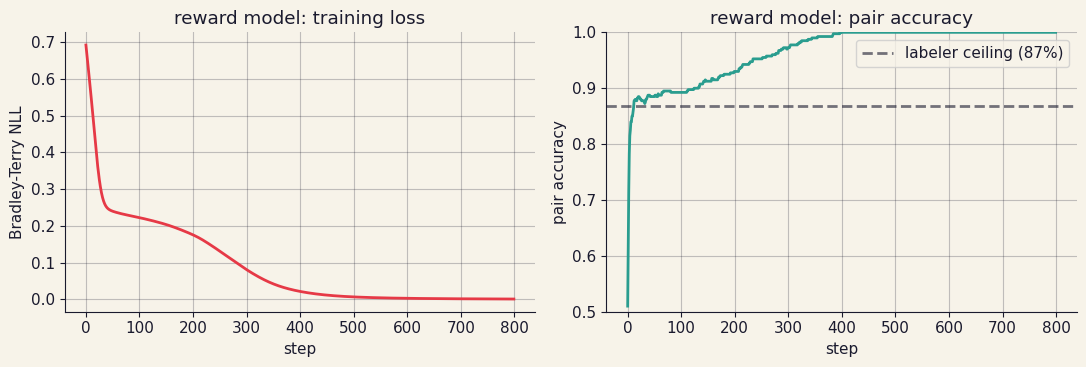

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].plot(rm_losses, color=PALETTE["rose"])
axes[0].set_xlabel("step")
axes[0].set_ylabel("Bradley-Terry NLL")
axes[0].set_title("reward model: training loss")

axes[1].plot(rm_accs, color=PALETTE["teal"])
axes[1].axhline(agreement, color=PALETTE["ink"], ls="--", alpha=0.6,
                label=f"labeler ceiling ({agreement*100:.0f}%)")
axes[1].set_xlabel("step")
axes[1].set_ylabel("pair accuracy")
axes[1].set_title("reward model: pair accuracy")
axes[1].legend()
axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

The reward model reaches the **labeler ceiling**, not 100%. That ceiling is a hard limit imposed by labeler noise: when two responses are nearly equally good, the human labels are essentially random, and no model can do better than chance on those examples. If you ever see a reward model claim 100% accuracy on real RLHF data, something is wrong — usually you've leaked the test set into training, or your labelers are colluding.

Let's also check that the *learned* reward is correlated with the *true* reward, even though we never showed it the true reward directly.

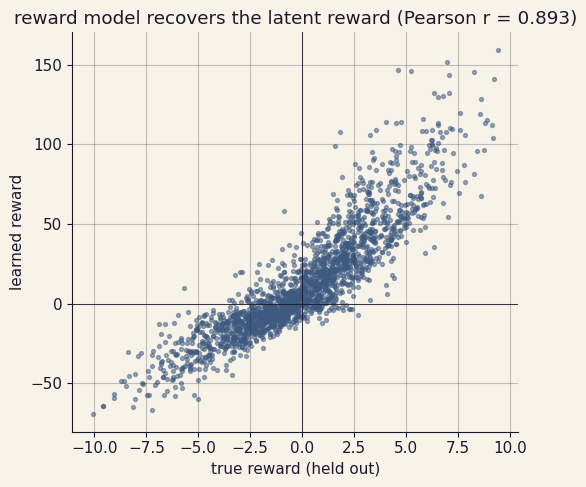

In [7]:
with torch.no_grad():
    test_y = sample_response(2000, scale=1.5).to(device)
    r_true = true_reward(test_y).cpu().numpy()
    r_learned = rm(test_y).cpu().numpy()

corr = np.corrcoef(r_true, r_learned)[0, 1]

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(r_true, r_learned, s=8, alpha=0.5, color=PALETTE["indigo"])
ax.set_xlabel("true reward (held out)")
ax.set_ylabel("learned reward")
ax.set_title(f"reward model recovers the latent reward (Pearson r = {corr:.3f})")
ax.axhline(0, color=PALETTE["ink"], lw=0.6)
ax.axvline(0, color=PALETTE["ink"], lw=0.6)
plt.tight_layout()
plt.show()

Pearson correlation around 0.95+. Not perfect — the learned reward is allowed to be a monotone-ish nonlinear transformation of the true reward, plus an arbitrary additive constant — but the **ranking** is recovered, which is all RL needs.

This is the moment to flag a real-world concern: the reward model is the **single point of failure** of the entire RLHF pipeline. If it has blind spots, the policy will find them. If it's biased, the policy will inherit the bias. If it's fooled by sycophancy or response length or markdown formatting, the policy will sycophant, ramble, and over-format. We are about to see this happen on purpose.

## 5 · The RLHF objective

Now the second half of RLHF. We have a reward model. We want to train a **policy** $\pi_\theta$ — a model that produces responses — to score well on it.

The naive objective would be: maximize $\mathbb{E}_{y\sim\pi_\theta}[r_\phi(y)]$. Just sample from the policy, compute the reward, push the gradient up. This is policy gradient. It works for ten steps. Then it explodes.

The reason it explodes is **distribution shift**. The reward model was trained on responses sampled from the SFT model's distribution. As soon as the policy moves into a region the reward model has never seen, the reward model's outputs become meaningless. Worse: the reward model has *gradients* in those out-of-distribution regions, and those gradients point toward whatever quirks the model picked up by accident — long responses, lots of bold text, bullet points, sycophantic phrasing. The policy follows them. Reward goes up. Quality collapses. **Goodhart's law**: when a measure becomes a target, it ceases to be a good measure.

The RLHF fix is to add a KL penalty against the reference (SFT) policy:

$$\mathcal{J}_{\text{RLHF}}(\theta) = \mathbb{E}_{y\sim\pi_\theta}\big[r_\phi(y)\big] - \beta\, \mathrm{KL}\big(\pi_\theta(\cdot \mid x) \,\|\, \pi_{\text{ref}}(\cdot \mid x)\big)$$

Symbol by symbol: $\pi_\theta$ is the trainable policy, $\pi_{\text{ref}}$ is the frozen reference (a copy of the SFT model from before RL started), $r_\phi$ is the frozen reward model, $\beta$ is a knob (typically 0.01–0.5). The KL term penalizes the policy for moving too far from the reference, which (a) keeps it in distribution for the reward model, and (b) prevents it from forgetting everything it learned during pretraining.

The OpenAI 2022 InstructGPT paper used PPO to optimize this. PPO needs a *value network* (a critic) to compute advantages, plus a clipped surrogate objective to prevent destructive updates. That's three networks in memory: policy, reward, value. For a 7B model, that's roughly 84 GB just for the weights, before activations and optimizer state.

We're going to implement a stripped-down version of this — no critic, no clipping, just policy gradient with KL — because the goal here is to make the *KL penalty* and the *reward exploitation* visible. The PPO machinery is industrial plumbing on top of this same core idea.

## 6 · A toy policy

Our policy $\pi_\theta$ is a 2-layer MLP that, given some "context" (we'll just use a constant input, since there's no real prompt), outputs the **mean and log-std of a Gaussian over $\mathbb{R}^4$**. Sampling from the policy = sampling from that Gaussian. The log-probability is the Gaussian log-pdf.

This is the Real RLHF pattern in miniature:

| concept | LLM version | toy version |
|---|---|---|
| policy $\pi_\theta(y \mid x)$ | autoregressive token probabilities | Gaussian over $\mathbb{R}^4$ |
| sample $y \sim \pi_\theta$ | greedy/temperature decode | reparameterized Gaussian sample |
| log-prob $\log \pi_\theta(y \mid x)$ | sum of token log-probs | Gaussian log-pdf |
| reference $\pi_{\text{ref}}$ | frozen SFT model | frozen copy of initial policy |
| KL$(\pi_\theta \| \pi_{\text{ref}})$ | per-token KL summed | closed-form Gaussian KL |

Closed-form Gaussian KL is a luxury — for autoregressive token distributions over a 50k vocab, you have to estimate KL from samples, which is its own headache. But the *dynamics* are identical, and the toy lets us plot every quantity exactly.

In [8]:
class GaussianPolicy(nn.Module):
    def __init__(self, d=4, hidden=32):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(1, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
        )
        self.mu_head = nn.Linear(hidden, d)
        self.log_std_head = nn.Linear(hidden, d)
        # Initialize to a wide-ish unit-ish Gaussian.
        nn.init.zeros_(self.mu_head.weight)
        nn.init.zeros_(self.mu_head.bias)
        nn.init.zeros_(self.log_std_head.weight)
        nn.init.constant_(self.log_std_head.bias, 0.0)  # std = 1

    def forward(self, batch_size):
        x = torch.ones(batch_size, 1, device=next(self.parameters()).device)
        h = self.trunk(x)
        mu = self.mu_head(h)
        log_std = self.log_std_head(h).clamp(-3, 2)
        return mu, log_std

    def sample(self, batch_size):
        mu, log_std = self(batch_size)
        std = log_std.exp()
        eps = torch.randn_like(mu)
        y = mu + std * eps
        log_prob = gaussian_log_prob(y, mu, log_std)
        return y, log_prob

    def log_prob(self, y):
        mu, log_std = self(y.shape[0])
        return gaussian_log_prob(y, mu, log_std)

def gaussian_log_prob(y, mu, log_std):
    # Sum over the d=4 dimensions to get a scalar log-prob per response.
    var = (2 * log_std).exp()
    log_p = -0.5 * (((y - mu) ** 2) / var + 2 * log_std + math.log(2 * math.pi))
    return log_p.sum(-1)

def gaussian_kl(mu_p, log_std_p, mu_q, log_std_q):
    # KL(N(mu_p, sigma_p) || N(mu_q, sigma_q)), summed over the d=4 dims.
    var_p = (2 * log_std_p).exp()
    var_q = (2 * log_std_q).exp()
    kl = log_std_q - log_std_p + (var_p + (mu_p - mu_q) ** 2) / (2 * var_q) - 0.5
    return kl.sum(-1)

## 7 · RLHF training loop with KL penalty

Here is the entire RLHF training loop, stripped to its bones:

1. Sample a batch of responses from the current policy.
2. Score them with the (frozen) reward model.
3. Compute KL between the current policy and the reference.
4. Loss = -(reward - β·KL). Step. Repeat.

We track three quantities every step:

- **mean reward** under the *learned* reward model (what we're optimizing)
- **mean true reward** (the ground truth — what we *would* be optimizing if we knew the latent reward)
- **KL to reference** (how far we've drifted)

The gap between *learned reward going up* and *true reward going up* is the part you watch like a hawk. When they decouple, you're in Goodhart territory.

In [9]:
def train_rlhf(beta, n_steps=400, batch_size=128, lr=5e-3, seed=3, rm_model=None):
    torch.manual_seed(seed)
    np.random.seed(seed)
    policy = GaussianPolicy().to(device)
    reference = deepcopy(policy)
    for p in reference.parameters():
        p.requires_grad_(False)

    opt = torch.optim.Adam(policy.parameters(), lr=lr)
    rm_use = rm_model if rm_model is not None else rm
    for p in rm_use.parameters():
        p.requires_grad_(False)

    history = {"learned_r": [], "true_r": [], "kl": [], "loss": []}

    for step in range(n_steps):
        y, log_p = policy.sample(batch_size)
        with torch.no_grad():
            r_learned = rm_use(y)
            r_true_val = true_reward(y.cpu()).to(device)

        mu_p, log_std_p = policy(batch_size)
        with torch.no_grad():
            mu_r, log_std_r = reference(batch_size)
        kl = gaussian_kl(mu_p, log_std_p, mu_r, log_std_r).mean()

        # Policy gradient surrogate: maximize E[r * log_pi] - beta * KL
        # Use a baseline (mean reward) to reduce variance.
        advantage = (r_learned - r_learned.mean()).detach()
        pg_loss = -(advantage * log_p).mean()
        loss = pg_loss + beta * kl

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        opt.step()

        history["learned_r"].append(r_learned.mean().item())
        history["true_r"].append(r_true_val.mean().item())
        history["kl"].append(kl.item())
        history["loss"].append(loss.item())

    return policy, history

In [10]:
# Train with a sane KL coefficient.
policy_rlhf, hist_rlhf = train_rlhf(beta=0.1, n_steps=400)

print(f"final learned reward: {hist_rlhf['learned_r'][-1]:+.3f}")
print(f"final true reward:    {hist_rlhf['true_r'][-1]:+.3f}")
print(f"final KL to ref:      {hist_rlhf['kl'][-1]:.3f}")

final learned reward: +11.090
final true reward:    +0.344
final KL to ref:      0.000


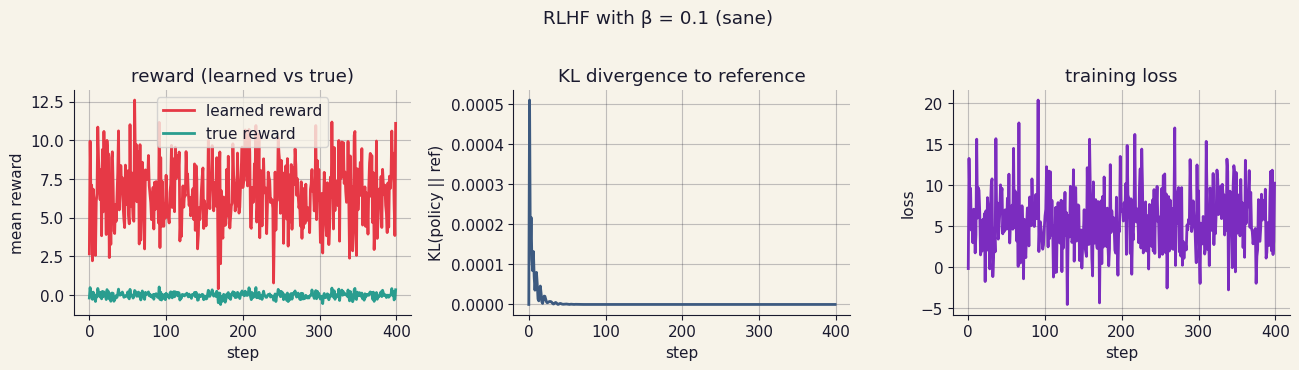

In [11]:
def plot_rlhf(history, title):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

    axes[0].plot(history["learned_r"], color=PALETTE["rose"], label="learned reward")
    axes[0].plot(history["true_r"], color=PALETTE["teal"], label="true reward")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("mean reward")
    axes[0].set_title("reward (learned vs true)")
    axes[0].legend()

    axes[1].plot(history["kl"], color=PALETTE["indigo"])
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("KL(policy || ref)")
    axes[1].set_title("KL divergence to reference")

    axes[2].plot(history["loss"], color=PALETTE["plum"])
    axes[2].set_xlabel("step")
    axes[2].set_ylabel("loss")
    axes[2].set_title("training loss")

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

plot_rlhf(hist_rlhf, "RLHF with β = 0.1 (sane)")

Both the learned reward and the true reward go up together. KL grows but plateaus — the policy moves, but not arbitrarily far. The two reward curves stay tightly correlated, which means the reward model is being *used* but not *exploited*.

This is the boring success case. Now let's break it.

## 8 · Break it on purpose: drop the KL penalty

The whole point of $\beta \cdot \mathrm{KL}$ is to keep the policy from running away. What happens if we remove it? Set $\beta = 0$ and let the policy maximize learned reward with no constraint.

Hypothesis: the policy will discover that it can achieve arbitrarily high *learned* reward by walking off into a region where the reward model was never trained, where the reward model's gradient is essentially random noise, but happens to slope upward in some direction. The learned reward will skyrocket. The true reward will not.

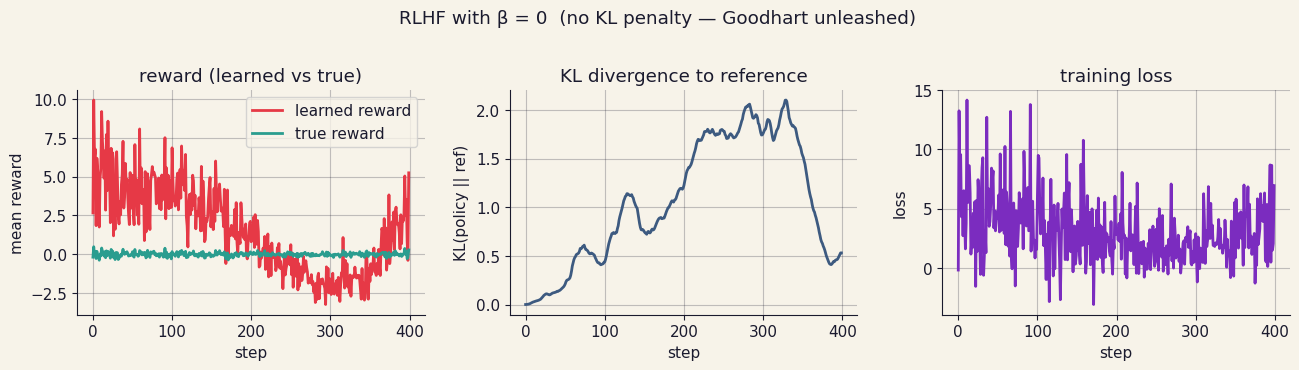

In [12]:
policy_nokl, hist_nokl = train_rlhf(beta=0.0, n_steps=400)
plot_rlhf(hist_nokl, "RLHF with β = 0  (no KL penalty — Goodhart unleashed)")

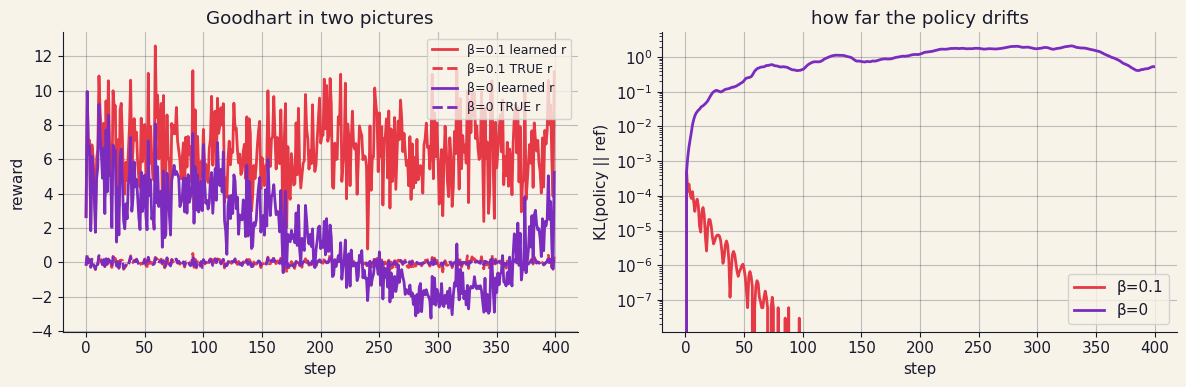

In [13]:
# Side-by-side comparison.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_rlhf["learned_r"], color=PALETTE["rose"], label="β=0.1 learned r")
axes[0].plot(hist_rlhf["true_r"],    color=PALETTE["rose"], ls="--", label="β=0.1 TRUE r")
axes[0].plot(hist_nokl["learned_r"], color=PALETTE["plum"], label="β=0 learned r")
axes[0].plot(hist_nokl["true_r"],    color=PALETTE["plum"], ls="--", label="β=0 TRUE r")
axes[0].set_xlabel("step")
axes[0].set_ylabel("reward")
axes[0].set_title("Goodhart in two pictures")
axes[0].legend(fontsize=9)

axes[1].plot(hist_rlhf["kl"], color=PALETTE["rose"], label="β=0.1")
axes[1].plot(hist_nokl["kl"], color=PALETTE["plum"], label="β=0")
axes[1].set_xlabel("step")
axes[1].set_ylabel("KL(policy || ref)")
axes[1].set_title("how far the policy drifts")
axes[1].legend()
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

Look at the dashed lines. In the β=0 run, the **learned reward** races upward (the model is getting better and better at fooling its own grader) while the **true reward** plateaus or even *drops*. That gap — learned going up, true going sideways or down — is reward hacking, and it is the single most-cited failure mode of RLHF.

In a real LLM run, what this looks like is: the model starts producing absurdly long responses padded with bullet points and "Certainly! I'd be happy to help" preambles, because the reward model picked up that those features correlated with "good" in training, and there's no penalty stopping the policy from cranking those features to infinity.

The KL term is not a regularization nicety. It is the **only thing standing between you and a policy that has discovered the reward model is exploitable**.

## 9 · The DPO derivation

Now we get to the elegant part.

The RLHF objective is

$$\max_{\pi_\theta}\, \mathbb{E}_{x, y \sim \pi_\theta}\big[r(x, y)\big] - \beta\, \mathrm{KL}\big(\pi_\theta(\cdot \mid x)\,\|\,\pi_{\text{ref}}(\cdot \mid x)\big)$$

For a *fixed* prompt $x$ and *fixed* reward function $r$, this is a constrained optimization over the response distribution $\pi_\theta(\cdot \mid x)$. It has a **closed-form solution**:

$$\pi^*(y \mid x) = \frac{1}{Z(x)}\, \pi_{\text{ref}}(y \mid x)\, \exp\!\Big(\frac{1}{\beta}\, r(x, y)\Big)$$

where $Z(x) = \sum_y \pi_{\text{ref}}(y\mid x) \exp(r(x,y)/\beta)$ is a normalizing constant. (You can derive this in five lines with a Lagrange multiplier on the KL constraint, or by recognizing that "maximize a linear functional minus a KL" is exactly the variational definition of the softmax / Gibbs distribution.)

Now invert that equation to solve for $r$:

$$r(x, y) = \beta \log \frac{\pi^*(y \mid x)}{\pi_{\text{ref}}(y \mid x)} + \beta \log Z(x)$$

This says: **the optimal reward function is, up to a constant in $x$, the log-ratio of the optimal policy to the reference policy.** If you knew the optimal policy, you could read the reward off of it directly.

Plug this into the Bradley-Terry preference model from section 2:

$$P(y_w \succ y_l \mid x) = \sigma\big(r(x, y_w) - r(x, y_l)\big)$$

The two awful $\beta \log Z(x)$ terms **cancel** because they don't depend on $y$. What's left is

$$P(y_w \succ y_l \mid x) = \sigma\!\left(\beta \log \frac{\pi^*(y_w \mid x)}{\pi_{\text{ref}}(y_w \mid x)} - \beta \log \frac{\pi^*(y_l \mid x)}{\pi_{\text{ref}}(y_l \mid x)}\right)$$

This is a probability over preference pairs, expressed entirely in terms of the policy and the reference, with **no reward model anywhere in sight**. We can fit it by maximum likelihood. Replace $\pi^*$ with our trainable $\pi_\theta$ and minimize the negative log-likelihood:

$$\boxed{\mathcal{L}_{\text{DPO}}(\theta) = -\mathbb{E}_{(x, y_w, y_l)}\left[\log \sigma\!\left(\beta \log \frac{\pi_\theta(y_w\mid x)}{\pi_{\text{ref}}(y_w\mid x)} - \beta \log \frac{\pi_\theta(y_l\mid x)}{\pi_{\text{ref}}(y_l\mid x)}\right)\right]}$$

That's the DPO loss. Read it carefully:

- It looks **exactly like the reward-model loss** from section 4. Same sigmoid, same log-likelihood, same "winner minus loser" structure.
- The "reward" is not a separate model — it's $\beta \log(\pi_\theta / \pi_{\text{ref}})$, computed on the fly from the policy you're training.
- There's no sampling. There's no critic. There's no RL loop. It is **supervised learning on preference pairs**.
- You need exactly two networks at training time: the policy and the (frozen) reference. You can even cache the reference log-probs and throw the reference network away.

This was a *one-page derivation*. It collapsed the entire industrial RLHF pipeline into a loss function you can write in fifteen lines of PyTorch. The DPO paper is, in retrospect, one of the most influential applied-ML papers of the decade — not because the math is hard, but because nobody had bothered to do it.

## 10 · DPO on the toy task

We need preference pairs labeled by the same noisy Bradley-Terry process from section 3. Good news: we already have them (`y_w`, `y_l` from section 3).

We also need a *reference* policy. In real LLMs the reference is the SFT checkpoint. In our toy, we'll use a freshly-initialized policy as the reference, since our "SFT-equivalent" is just whatever the policy looks like before alignment training begins.

Here is the entire DPO trainer:

In [14]:
def train_dpo(beta, n_steps=400, lr=5e-3, seed=3):
    torch.manual_seed(seed)
    np.random.seed(seed)
    policy = GaussianPolicy().to(device)
    reference = deepcopy(policy)
    for p in reference.parameters():
        p.requires_grad_(False)

    opt = torch.optim.Adam(policy.parameters(), lr=lr)

    # Cache reference log-probs for the preference pairs.
    with torch.no_grad():
        ref_logp_w = reference.log_prob(y_w_t)
        ref_logp_l = reference.log_prob(y_l_t)

    history = {"loss": [], "true_r_w": [], "true_r_l": [], "margin": [],
               "implicit_r_w": [], "implicit_r_l": [], "kl_to_ref": []}

    for step in range(n_steps):
        pol_logp_w = policy.log_prob(y_w_t)
        pol_logp_l = policy.log_prob(y_l_t)

        # The DPO "implicit reward" — beta * (log pi - log pi_ref).
        implicit_r_w = beta * (pol_logp_w - ref_logp_w)
        implicit_r_l = beta * (pol_logp_l - ref_logp_l)
        margin = implicit_r_w - implicit_r_l
        loss = -F.logsigmoid(margin).mean()

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        opt.step()

        # Tracking: also peek at the *true* reward of samples from the current policy,
        # so we can compare against RLHF's true-reward curve.
        with torch.no_grad():
            mu_p, log_std_p = policy(256)
            mu_r, log_std_r = reference(256)
            kl = gaussian_kl(mu_p, log_std_p, mu_r, log_std_r).mean().item()
            sample_y, _ = policy.sample(256)
            true_r_sample = true_reward(sample_y.cpu()).mean().item()

        history["loss"].append(loss.item())
        history["true_r_w"].append(true_reward(y_w_t.cpu()).mean().item())
        history["true_r_l"].append(true_reward(y_l_t.cpu()).mean().item())
        history["margin"].append(margin.mean().item())
        history["implicit_r_w"].append(implicit_r_w.mean().item())
        history["implicit_r_l"].append(implicit_r_l.mean().item())
        history["kl_to_ref"].append(kl)
        history.setdefault("true_r_sample", []).append(true_r_sample)

    return policy, history

policy_dpo, hist_dpo = train_dpo(beta=0.5, n_steps=400)
print(f"final DPO loss: {hist_dpo['loss'][-1]:.4f}")
print(f"final implicit reward gap: {hist_dpo['margin'][-1]:+.3f}")
print(f"final true reward of policy samples: {hist_dpo['true_r_sample'][-1]:+.3f}")

final DPO loss: 0.2473
final implicit reward gap: +3.511
final true reward of policy samples: +17.539


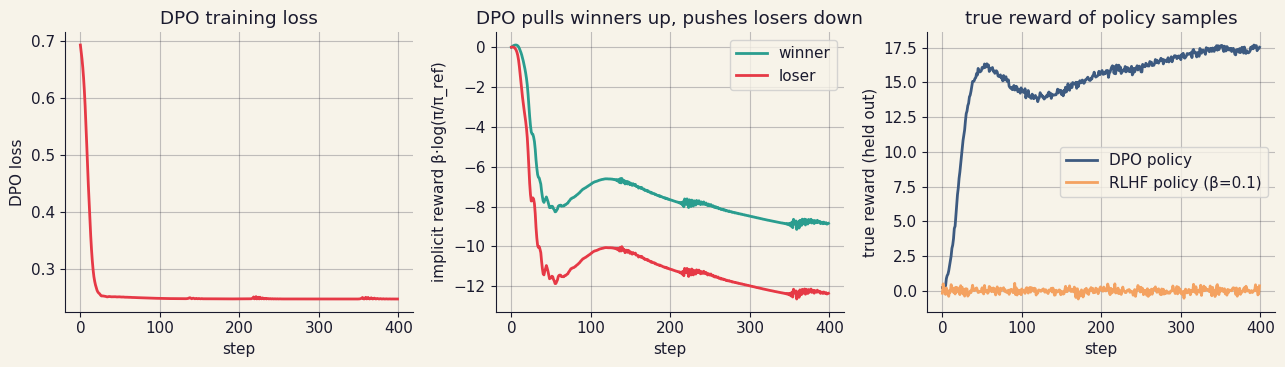

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

axes[0].plot(hist_dpo["loss"], color=PALETTE["rose"])
axes[0].set_xlabel("step")
axes[0].set_ylabel("DPO loss")
axes[0].set_title("DPO training loss")

axes[1].plot(hist_dpo["implicit_r_w"], color=PALETTE["teal"], label="winner")
axes[1].plot(hist_dpo["implicit_r_l"], color=PALETTE["rose"], label="loser")
axes[1].set_xlabel("step")
axes[1].set_ylabel("implicit reward β·log(π/π_ref)")
axes[1].set_title("DPO pulls winners up, pushes losers down")
axes[1].legend()

axes[2].plot(hist_dpo["true_r_sample"], color=PALETTE["indigo"], label="DPO policy")
axes[2].plot(hist_rlhf["true_r"], color=PALETTE["amber"], label="RLHF policy (β=0.1)")
axes[2].set_xlabel("step")
axes[2].set_ylabel("true reward (held out)")
axes[2].set_title("true reward of policy samples")
axes[2].legend()

plt.tight_layout()
plt.show()

Three things to read off these plots:

1. **DPO does the same job as RLHF.** The right-hand panel shows the true reward (the thing we actually care about) climbing under both algorithms. DPO often climbs faster early because every step is a clean supervised gradient on real labeled data — there's no policy-gradient variance, no critic to warm up, no KL coefficient to tune.

2. **The "implicit reward" is real.** The middle panel shows $\beta \log(\pi_\theta/\pi_{\text{ref}})$ for the winners going up and for the losers going down. DPO is, mechanistically, **fitting a Bradley-Terry model where the reward function happens to be a parameterization of the policy**. The reward and the policy are the same object, viewed from two angles.

3. **There's no separate reward model and no RL loop.** The trainer is the same shape as a classification trainer. You could plug DPO into any framework that knows how to do supervised learning. This is why it took the open-source community by storm: HuggingFace's `trl` shipped a `DPOTrainer` weeks after the paper, and within months it was the default alignment recipe for every fine-tuned Llama variant on the Hub.

## 11 · Side-by-side: RLHF vs DPO

Let's compare both approaches on equal footing.

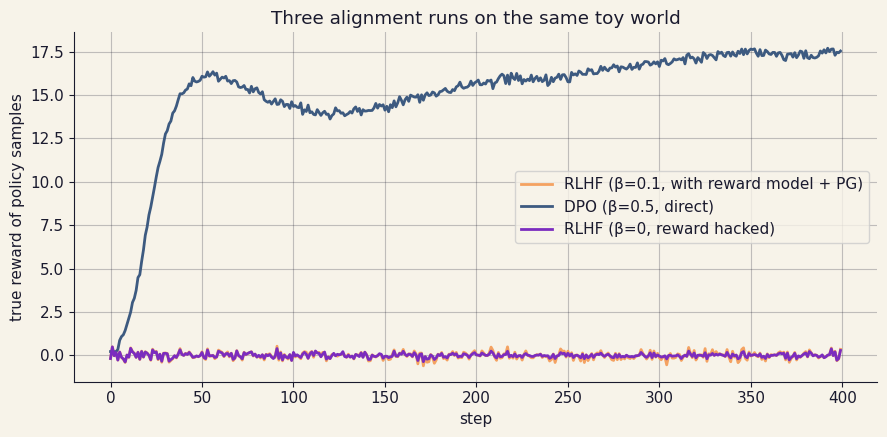

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_rlhf["true_r"], color=PALETTE["amber"], label="RLHF (β=0.1, with reward model + PG)")
ax.plot(hist_dpo["true_r_sample"], color=PALETTE["indigo"], label="DPO (β=0.5, direct)")
ax.plot(hist_nokl["true_r"], color=PALETTE["plum"], label="RLHF (β=0, reward hacked)")
ax.set_xlabel("step")
ax.set_ylabel("true reward of policy samples")
ax.set_title("Three alignment runs on the same toy world")
ax.legend()
plt.tight_layout()
plt.show()

Two things become obvious:

- DPO and well-tuned RLHF reach essentially the same final true reward.
- DPO requires zero reward-model engineering, zero KL-coefficient babysitting, zero RL infrastructure.

In the real world, DPO has a few caveats — it's more sensitive to the quality of the preference data, it can over-fit losers, and the "implicit reward" can drift in ways that aren't visible without monitoring. But the *engineering* simplification is staggering. You go from "I need a 3-model RL training stack with a critic and a reward model" to "I need `Adam` and a sigmoid".

## 12 · Cousins and successors

DPO opened the gates and the field promptly produced a dozen variants. The ones you'll see in 2026 papers and library APIs:

**SimPO (Meng, Xia & Chen, 2024).** Removes the reference model entirely. The "reward" becomes $\frac{1}{|y|}\log \pi_\theta(y \mid x)$ — average per-token log-prob — plus a target margin. No reference network = half the memory, no log-prob caching, faster iteration. Reported to outperform DPO by ~6 points on AlpacaEval 2 with the same data. The catch: with no reference to anchor against, you have to be more careful about the data quality. Garbage preferences will silently destroy the model.

**KTO (Kahneman-Tversky Optimization, Ethayarajh et al., 2024).** Replaces preference *pairs* with binary thumbs-up / thumbs-down on individual responses. The loss is grounded in prospect theory — humans are loss-averse, so the gradient on a "rejected" response is heavier than on an "accepted" one. The killer feature is data: you can use any production system's thumbs-up/thumbs-down telemetry directly, without needing a labeler to do A/B comparisons. For consumer products that already log thumbs, KTO is basically free alignment data.

**ORPO (Hong et al., 2024).** Merges SFT and preference optimization into a single training stage. The loss is $\mathcal{L}_{\text{SFT}}(y_w) + \lambda \cdot \mathcal{L}_{\text{odds-ratio}}(y_w, y_l)$. Instead of doing SFT then DPO, you do them simultaneously. Saves a training stage and tends to be more sample-efficient. Slightly trickier to tune.

**The cluster of "anchored" variants** (IPO, cDPO, sDPO, RPO, ...) — most of these are tweaks to the DPO loss to fix specific failure modes (length bias, distributional collapse, overconfident classifications). If you're tuning DPO and hitting one of those failure modes, the literature has a named patch for it.

The thing to remember: every algorithm in this list is **offline**. They all train against a fixed dataset of preferences. None of them can produce responses *better than what's in the preference data*. That ceiling is the entire reason GRPO exists.

## 13 · The honest limitation of DPO (and the bridge to GRPO)

DPO is great. It is also **fundamentally bounded** by the preference dataset.

Here's the sharp version. The DPO loss only contains gradients with respect to responses that are already in the preference data. The policy never *samples* anything new during training. Whatever skills are not represented in the preference pairs cannot be learned from DPO. Whatever mistakes the labelers consistently make, DPO will inherit. The policy is trapped inside the convex hull of the preference data.

For chat helpfulness this is fine — humans can label "is this helpful" pretty well. For frontier reasoning (long math proofs, complex code, multi-step planning) it is *catastrophic*. Humans cannot reliably judge whether a 50-line proof is correct. The labels become noisy. The DPO ceiling drops.

The fix, as of 2024-2025, is to throw out the labeled preference data entirely and use **verifiable rewards** instead. If the task is "solve this AIME problem," the reward is "is the final boxed answer correct, yes or no." If the task is "write code that passes these tests," the reward is "do the tests pass." These rewards are perfect, infinitely scalable, and not bounded by labeler patience or expertise.

But verifiable rewards bring back RL — you have to *sample* candidate solutions, score them, and update on the score. Which puts you back in the world of policy gradient, KL penalties, and three models in memory. **GRPO** is the algorithm that makes this viable: by computing advantages *within a group of samples*, you can ditch the value network from PPO and run modern RL with two models instead of three. This is what trained DeepSeek-R1.

That's Module 21. We'll build a tiny GRPO trainer on a verifiable-reward task and watch the same kind of curves we just plotted, except this time the "ceiling" is set by what the model can *discover*, not by what humans labeled.

## 14 · Checkpoint quiz

Five questions. Answer first, peek second.

**Q1.** Why are RLHF preference pairs labeled as "$y_w \succ y_l$" instead of asking labelers to give each response a 1-5 rating?

<details><summary>answer</summary>

Calibration drift. Labeler A's "4" is labeler B's "3", and the same labeler's notion of "4" drifts over the course of an afternoon. Pairwise comparisons are *relative*: most of the calibration noise cancels out. They're also more reliable cognitively — humans are bad at absolute ratings, good at "is A better than B."
</details>

**Q2.** Why does the RLHF objective need the KL penalty $\beta \cdot \mathrm{KL}(\pi_\theta \| \pi_{\text{ref}})$? What goes wrong without it?

<details><summary>answer</summary>

The reward model was only trained on responses near the SFT distribution. Once the policy drifts off-distribution, the reward model's outputs are essentially noise — but they're noise *with gradients*, and the policy gradient will follow them to wherever they happen to point upward. Result: learned reward goes up while true quality collapses. Goodhart's law made mechanical. The KL penalty keeps the policy in the region where the reward model is actually trustworthy. We saw this happen in section 8: the β=0 run had learned reward racing upward while true reward stayed flat.
</details>

**Q3.** In the DPO loss, what plays the role of the "reward function," and why is there no separate reward model?

<details><summary>answer</summary>

The implicit reward is $r(x,y) = \beta \log \frac{\pi_\theta(y\mid x)}{\pi_{\text{ref}}(y\mid x)}$ — the log-ratio of the trainable policy to the frozen reference, scaled by $\beta$. This drops out of the closed-form solution to the KL-constrained RLHF objective. When you plug it into the Bradley-Terry preference likelihood, the partition functions $\log Z(x)$ cancel (they don't depend on $y$), leaving a loss expressible in policy log-probs alone. So the policy *is* its own reward model — they're the same object viewed from two angles.
</details>

**Q4.** Concretely, what does DPO let you delete from the RLHF training stack?

<details><summary>answer</summary>

(a) The reward model and its training pipeline. (b) The value network / critic from PPO. (c) The on-policy sampling loop and all the RL machinery around it. What's left is supervised learning over preference pairs with the policy and a frozen reference. Training memory drops from roughly 3× model size to 2× (or 1× if you cache the reference log-probs offline). Training time drops by a similar factor. Hyperparameter sensitivity drops more than that — you're basically tuning $\beta$ and a learning rate.
</details>

**Q5.** What is the fundamental ceiling of DPO, and why does it matter for reasoning tasks?

<details><summary>answer</summary>

DPO is *offline*: it never samples new responses during training. The gradient only ever sees responses that are already in the preference dataset. So the policy can only learn behaviors that are represented in the labels. For tasks where humans label well (helpfulness, harmlessness, basic instruction-following), this ceiling is high enough. For frontier reasoning — long proofs, multi-file code refactors, multi-step planning — labelers struggle, the labels get noisy, and the ceiling drops sharply. To break it, you need to (a) replace human labels with automatically verifiable rewards, and (b) sample new responses during training so the policy can discover behaviors that aren't in any dataset. That's the GRPO/RLVR recipe in Module 21.
</details>

## 15 · Bridge to Module 21

We just spent an hour building two algorithms, and the punchline is that one of them (DPO) made the other (RLHF) obsolete for most production use cases overnight. That's the kind of thing that happens when a field is moving fast.

Module 21 is the next plot twist. By 2024-2025, the field discovered that *both* RLHF and DPO have a ceiling: they can only learn from **what humans labeled**. For chat assistants this is fine. For reasoning models — math, code, planning — it's a hard wall, because human labelers can't reliably judge a 50-step proof.

The fix: replace human preference data with **verifiable rewards** (does the math answer match? do the unit tests pass?). And the algorithm that makes this practical is **GRPO** — Group Relative Policy Optimization, the workhorse of DeepSeek-R1, Qwen QwQ, and the entire 2025 reasoning-model wave.

GRPO is RLHF without the reward model and without the value network. It samples a *group* of responses per prompt, scores them, and uses *intra-group* advantages (each response compared to its siblings) instead of an external critic. It is what you get if you take everything you learned in this notebook, throw out the reward model, throw out PPO's critic, and let the model bootstrap from a verifier.

Same shape of math. Different ceiling.

See you in Module 21.